In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

sns.set_theme(style="whitegrid", palette="viridis")

In [ ]:
try:
    data = pd.read_csv("sample_data/purba_medinipur_rice_detailed.csv")
    print("✅ Dataset loaded successfully!")
    display(data.head())
except FileNotFoundError:
    print("❌ Error: CSV not found.")

✅ Dataset loaded successfully!


,Year,District,Rice_Yield_t_ha,year,week_1_precip,week_1_LST,week_2_precip,week_2_LST,week_3_precip,week_3_LST,...,fortnight_7_precip,fortnight_7_LST,fortnight_8_precip,fortnight_8_LST,fortnight_9_precip,fortnight_9_LST,fortnight_10_precip,fortnight_10_LST,fortnight_11_precip,fortnight_11_LST
0,2001,Purba Medinipur,2.85,2001,0.0,27.850000,2.552571,27.934143,0.099857,24.850143,...,0.051071,28.753429,1.701786,29.127714,0.000000,32.632286,3.192643,30.881214,0.563167,34.234167
1,2002,Purba Medinipur,2.91,2002,0.0,27.665000,0.000000,27.497429,0.000000,26.023429,...,0.556357,26.618143,0.210357,29.301214,0.666000,31.285929,2.234071,18.847786,0.814167,30.047583
2,2003,Purba Medinipur,3.02,2003,0.0,25.943714,0.080286,25.254000,0.000000,25.848000,...,0.593929,26.833929,0.013500,28.439214,3.407857,27.798571,0.514286,29.993071,1.234417,29.949917
3,2004,Purba Medinipur,3.15,2004,0.0,26.871143,0.000286,25.338857,0.000000,24.686429,...,0.003571,26.637357,0.000000,30.565857,0.547143,30.772571,1.219857,31.598143,1.576154,30.791846
4,2005,Purba Medinipur,3.21,2005,0.0,26.687571,0.629714,26.496286,0.000000,26.278429,...,0.634857,28.269786,0.048000,29.894571,1.701643,29.913429,1.788286,29.533714,0.421667,30.851333


In [ ]:
TARGET = "Rice_Yield_t_ha"

exclude_cols = ["Year", "District", TARGET, "year"]

feature_cols = [col for col in data.columns if col not in exclude_cols]

print(f"Identified {len(feature_cols)} feature columns.")
feature_cols

Identified 66 feature columns.


['week_1_precip',
 'week_1_LST',
 'week_2_precip',
 'week_2_LST',
 'week_3_precip',
 'week_3_LST',
 'week_4_precip',
 'week_4_LST',
 'week_5_precip',
 'week_5_LST',
 'week_6_precip',
 'week_6_LST',
 'week_7_precip',
 'week_7_LST',
 'week_8_precip',
 'week_8_LST',
 'week_9_precip',
 'week_9_LST',
 'week_10_precip',
 'week_10_LST',
 'week_11_precip',
 'week_11_LST',
 'week_12_precip',
 'week_12_LST',
 'week_13_precip',
 'week_13_LST',
 'week_14_precip',
 'week_14_LST',
 'week_15_precip',
 'week_15_LST',
 'week_16_precip',
 'week_16_LST',
 'week_17_precip',
 'week_17_LST',
 'week_18_precip',
 'week_18_LST',
 'week_19_precip',
 'week_19_LST',
 'week_20_precip',
 'week_20_LST',
 'week_21_precip',
 'week_21_LST',
 'week_22_precip',
 'week_22_LST',
 'fortnight_1_precip',
 'fortnight_1_LST',
 'fortnight_2_precip',
 'fortnight_2_LST',
 'fortnight_3_precip',
 'fortnight_3_LST',
 'fortnight_4_precip',
 'fortnight_4_LST',
 'fortnight_5_precip',
 'fortnight_5_LST',
 'fortnight_6_precip',
 'fortnigh

In [ ]:
original_features = feature_cols.copy()

weeks = sorted(list(set([
    int(col.split('_')[1]) for col in feature_cols if "week_" in col
])))

num_weeks = len(weeks)
print(f"Detected {num_weeks} weeks.")

# FIX: explicitly set features per week
features_per_week = 2
print(f"Detected {features_per_week} features per week.")

X_seq = []

for _, row in data.iterrows():
    seq = []
    for w in weeks:
        seq.append([
            row[f"week_{w}_precip"],
            row[f"week_{w}_LST"]
        ])
    X_seq.append(seq)

X_seq = np.array(X_seq)
y = data[TARGET].values

print("Final CNN input shape:", X_seq.shape)

Detected 22 weeks.
Detected 2 features per week.
Final CNN input shape: (24, 22, 2)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_r = X_train.reshape(-1, features_per_week)
X_test_r  = X_test.reshape(-1, features_per_week)

scaler.fit(X_train_r)

X_train_scaled = scaler.transform(X_train_r).reshape(X_train.shape)
X_test_scaled  = scaler.transform(X_test_r).reshape(X_test.shape)

print("Scaling completed.")

Scaling completed.


In [ ]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (19, 22, 2)
X_test_scaled shape: (5, 22, 2)


In [ ]:
model = Sequential([

    Conv1D(filters=64, kernel_size=2, activation='relu',
           input_shape=(num_weeks, features_per_week)),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=32, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 21, 64)         │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 9, 32)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,817 (57.88 KB)

 Trainable params: 14,817 (57.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True,
    monitor='val_loss',
    mode='min'
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 9.5103 - mae: 3.0760 - val_loss: 9.0862 - val_mae: 3.0047
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 9.2416 - mae: 3.0334 - val_loss: 8.8437 - val_mae: 2.9645
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 8.6830 - mae: 2.9394 - val_loss: 8.5617 - val_mae: 2.9166
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 8.5861 - mae: 2.9208 - val_loss: 8.2285 - val_mae: 2.8588
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 8.2227 - mae: 2.8623 - val_loss: 7.8676 - val_mae: 2.7949
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 7.7667 - mae: 2.7769 - val_loss: 7.5117 - val_mae: 2.7304
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 7.4672 - mae: 2.7200 - val_loss: 7.1480 - val_mae: 2.6632
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 7.0388 - mae: 2.6378 - val_loss: 6.7696 - val_mae: 2.5914
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 6.7018 - 


📈 CNN Evaluation Results:
MAE: 0.7694


MSE: 0.8235
R2 Score: -22.7334


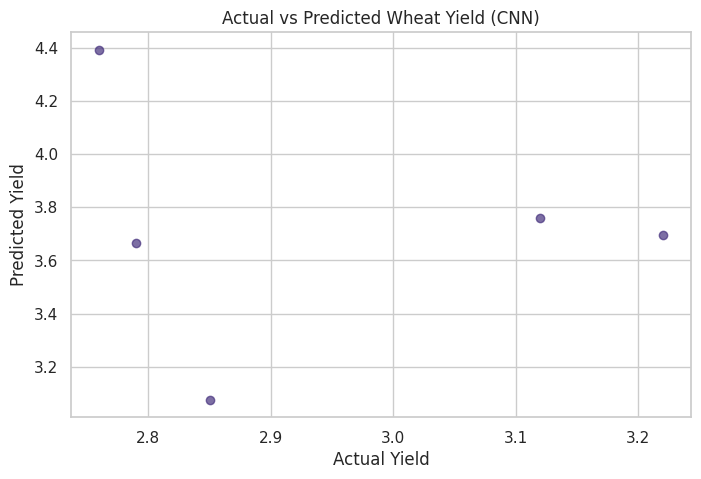

In [ ]:
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print("\n📈 CNN Evaluation Results:")
print(f"MAE: {mae:.4f}")

y_pred = model.predict(X_test_scaled, verbose=0)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Wheat Yield (CNN)")
plt.show()